# Funções do 1º Grau

**Módulo:** 01 – Conjuntos e Funções

**Pré-requisitos:** [`015a_funcoes.ipynb`](015a_funcoes.ipynb) (conceito de função, domínio/contradomínio/imagem, gráfico no plano cartesiano) e [`016a_classificacao_e_operacoes_com_funcoes.ipynb`](016a_classificacao_e_operacoes_com_funcoes.ipynb) (funções crescentes e decrescentes), além do Python básico de [00_fundamentos_e_python/](../00_fundamentos_e_python/) (`def`, `matplotlib` simples) e resolução de equações do 1º grau

**Objetivos de aprendizagem:**
- Reconhecer e diferenciar função constante, identidade, linear e afim.
- Construir e interpretar o gráfico de uma função afim a partir da lei ou de dois pontos conhecidos.
- Calcular o zero de uma função afim e usá-lo para determinar seu sinal.
- Resolver inequações simultâneas, -produto e -quociente envolvendo funções afins.

**Tempo estimado:** 90 a 120 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/01_conjuntos_e_funcoes/017a_funcoes_primeiro_grau.ipynb)

## A bateria que não avisa quando vai acabar

Você está jogando no celular e percebe que a bateria está caindo rápido. Olha a tela duas vezes durante a partida:

- Depois de **1 hora** de jogo, a bateria estava em **88%**.
- Depois de **3 horas** de jogo, a bateria estava em **64%**.

Nesse ritmo, dá para prever, sem esperar o celular desligar sozinho, **quantas horas de jogo ainda restam** até a bateria chegar a 0%?

Ainda não vamos responder — só guardar essa pergunta. Ao longo deste notebook vamos ver que esse tipo de situação (algo que começa em um valor e varia numa taxa constante) é descrito por um dos objetos mais úteis da matemática: a **função afim**.

## Função afim: definição geral

- 📌 **Definição formal:** uma função f: R → R é chamada de **função afim** (ou função polinomial do 1º grau) quando pode ser escrita na forma **f(x) = ax + b**, com a, b ∈ R.
- No cenário da bateria existe uma taxa constante de consumo e uma carga inicial — é exatamente essa estrutura ("taxa constante vezes x, mais um valor inicial") que a função afim descreve.
- a e b são chamados de **coeficientes** da função afim (o papel de cada um vai ficar mais claro daqui a pouco).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sympy as sp
import ipywidgets as widgets
from IPython.display import display

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"


def estilizar_eixo(ax) -> None:
    '''Aplica o estilo Nord padrão a um eixo do matplotlib.'''
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)


def funcao_afim(x, a, b):
    '''f(x) = a*x + b'''
    return a * x + b


# cenário: bateria de celular jogando um jogo que consome carga a taxa
# constante -- carga inicial de 100%, caindo 12 pontos percentuais por hora
taxa_consumo = -12    # a: variação percentual por hora (negativo: a carga cai)
carga_inicial = 100   # b: carga (%) no instante x=0

horas_gancho = [1, 3]
cargas_reais = [88, 64]

for x, carga_real in zip(horas_gancho, cargas_reais):
    carga_prevista = funcao_afim(x, taxa_consumo, carga_inicial)
    print(f"x = {x}h  ->  previsto: {carga_prevista:g}%   real: {carga_real}%")

x = 1h  ->  previsto: 88%   real: 88%
x = 3h  ->  previsto: 64%   real: 64%


**Perguntas de checagem:**
1. Se dobrarmos o valor de x (por exemplo, de 1h para 2h de jogo), f(x) também dobra? Por quê?
2. O que aconteceria com a previsão se b (carga inicial) fosse diferente, mas a (taxa) continuasse a mesma?

## Casos particulares da função afim

- 📌 **Função constante:** quando a = 0, f(x) = b para todo x — o valor não muda, não importa o x.
- 📌 **Função linear:** quando b = 0, f(x) = ax — é o caso de proporcionalidade direta: dobrar x dobra f(x).
- 📌 **Função identidade:** quando a = 1 e b = 0, f(x) = x — a função "devolve" o próprio x.
- 💡 **Dica:** constante, linear e identidade não são "outra coisa" — são casos particulares da mesma função afim f(x) = ax+b, só com valores específicos de a e b.
- ⚠️ **Erro comum:** em português, "função linear" tem esse significado técnico e restrito (b = 0). No dia a dia — e até em outras disciplinas — é comum chamar qualquer reta de "linear", inclusive uma reta com b ≠ 0. Neste curso, sempre que dissermos "linear" no sentido técnico, isso vai significar b = 0.

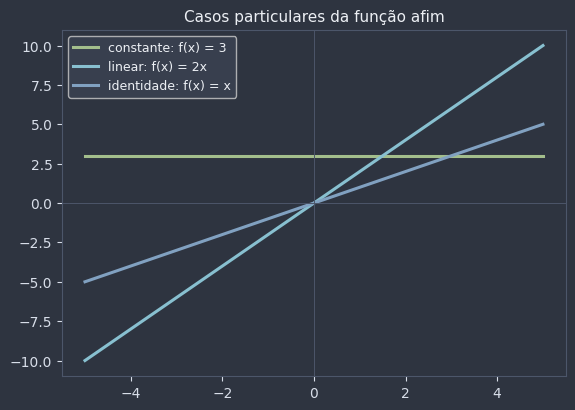

In [2]:
xs_casos = np.linspace(-5, 5, 200)

funcoes_particulares = [
    ("constante: f(x) = 3", funcao_afim(xs_casos, 0, 3), COR_DESTAQUE),
    ("linear: f(x) = 2x", funcao_afim(xs_casos, 2, 0), COR_PONTO),
    ("identidade: f(x) = x", funcao_afim(xs_casos, 1, 0), COR_SECUNDARIA),
]

fig, ax = plt.subplots(figsize=(6.5, 4.5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
for nome, ys, cor in funcoes_particulares:
    ax.plot(xs_casos, ys, color=cor, linewidth=2.2, label=nome)
ax.axhline(0, color=NORD_LINHA, linewidth=0.7)
ax.axvline(0, color=NORD_LINHA, linewidth=0.7)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=9)
ax.set_title("Casos particulares da função afim", color=NORD_TEXTO, fontsize=11)
plt.show()

**Perguntas de checagem:**
1. Que valores de a e b fariam a função afim da bateria (f(x) = -12x + 100) virar uma função constante? Isso faria sentido fisicamente?
2. A função identidade f(x) = x é um caso particular da família linear (b = 0) ou da família constante (a = 0)? Por quê?

## O gráfico é sempre uma reta

- Repare, na tabela de valores que vamos montar a seguir, que cada vez que x aumenta em 1 unidade, f(x) muda sempre pela mesma quantidade (o valor de a). Essa "variação constante" é o motivo — de forma intuitiva, não uma prova formal — pelo qual o gráfico de uma função afim é sempre uma **reta**.
- 📌 **Coeficiente angular e coeficiente linear:** em f(x) = ax + b, **a** é o **coeficiente angular** (mede a inclinação da reta: quanto f(x) muda por unidade de x) e **b** é o **coeficiente linear** (é o valor de f(0), o ponto onde a reta corta o eixo y).

In [3]:
def explorar_afim(a: float, b: float) -> None:
    xs = np.linspace(-2, 15, 200)
    ys = funcao_afim(xs, a, b)

    fig, ax = plt.subplots(figsize=(6.5, 4.3))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.plot(xs, ys, color=COR_DESTAQUE, linewidth=2.4)
    ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
    ax.axvline(0, color=NORD_LINHA, linewidth=0.8)
    ax.set_xlabel("x (horas)", color=NORD_TEXTO_SEC)
    ax.set_ylabel("f(x) (%)", color=NORD_TEXTO_SEC)
    ax.set_title(f"f(x) = {a:g}x + {b:g}", color=NORD_TEXTO, fontsize=11)
    plt.show()

    print(f"fórmula: f(x) = {a:g}x + {b:g}")
    tabela = pd.DataFrame({"x": np.round(np.linspace(0, 8, 5), 2)})
    tabela["f(x)"] = np.round(funcao_afim(tabela["x"], a, b), 2)
    display(tabela)


widgets.interact(
    explorar_afim,
    a=widgets.FloatSlider(value=-12.0, min=-20, max=20, step=1, description="a (taxa):"),
    b=widgets.FloatSlider(value=100.0, min=-20, max=100, step=5, description="b (carga inicial):"),
)

interactive(children=(FloatSlider(value=-12.0, description='a (taxa):', max=20.0, min=-20.0, step=1.0), FloatS…

<function __main__.explorar_afim(a: float, b: float) -> None>

## Determinando a lei a partir de dois pontos

- 📌 **Método:** se conhecemos dois pontos, (x1, f(x1)) e (x2, f(x2)), de uma função afim, mas não sabemos a e b, montamos um sistema de duas equações — uma para cada ponto — e resolvemos para a e b.
- Voltando ao cenário da bateria: e se você só tivesse anotado "1h → 88%" e "3h → 64%", sem saber de antemão que a taxa era -12%/h? Dá para descobrir a lei completa só com esses dois pontos.

a = -12, b = 100


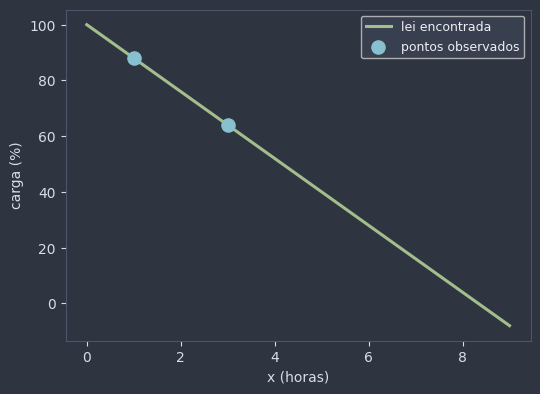

In [4]:
a_sym, b_sym, x_sym = sp.symbols("a b x")

eq1 = sp.Eq(a_sym * 1 + b_sym, 88)
eq2 = sp.Eq(a_sym * 3 + b_sym, 64)

solucao = sp.solve([eq1, eq2], [a_sym, b_sym])
a_encontrado = solucao[a_sym]
b_encontrado = solucao[b_sym]
print(f"a = {a_encontrado}, b = {b_encontrado}")

xs_verif = np.linspace(0, 9, 200)
fig, ax = plt.subplots(figsize=(6, 4.3))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.plot(
    xs_verif, funcao_afim(xs_verif, float(a_encontrado), float(b_encontrado)),
    color=COR_DESTAQUE, linewidth=2.2, label="lei encontrada",
)
ax.scatter([1, 3], [88, 64], s=90, color=COR_PONTO, zorder=3, label="pontos observados")
ax.set_xlabel("x (horas)", color=NORD_TEXTO_SEC)
ax.set_ylabel("carga (%)", color=NORD_TEXTO_SEC)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=9)
plt.show()

📌 Resolver esse sistema de duas equações e duas incógnitas (a e b) é, na prática, resolver um **sistema linear 2x2** — métodos gerais para isso (substituição, eliminação, forma matricial) aparecem no módulo `03_progressoes_matrizes_e_sistemas_lineares`.

**Perguntas de checagem:**
1. Por que são necessários **dois** pontos (e não apenas um) para determinar a e b de uma função afim?
2. Se os dois pontos observados tivessem o mesmo valor de f(x) (por exemplo, 88% nas duas medições), o que isso indicaria sobre a?

## Imagem da função afim

- 📌 **Caso geral (a ≠ 0):** Im(f) = R — para qualquer valor real y existe algum x tal que f(x) = y (basta isolar x na equação ax+b=y).
- 📌 **Caso constante (a = 0):** Im(f) = {b} — a função só assume o único valor b.
- Olhando o gráfico da bateria: como a reta não é horizontal (a ≠ 0), ela cobre verticalmente todos os valores reais — inclusive valores negativos de carga, que não fazem sentido fisicamente, mas são matematicamente parte da reta completa. Voltamos a isso já no zero, a seguir.

## Zero da função afim

- 📌 **Definição:** o zero (ou raiz) de uma função afim é o valor de x tal que f(x) = 0.
- Partindo de ax + b = 0, isolamos x: **x = -b/a** (definido apenas para a ≠ 0).
- Interpretação gráfica: é o ponto onde a reta cruza o eixo x.
- No cenário da bateria, o zero é exatamente a resposta para a pergunta do gancho: quantas horas até a carga chegar a 0%.

zero: x = -b/a = -(100)/(-12) = 8.33 horas
ou seja, aproximadamente 8h20min de bateria


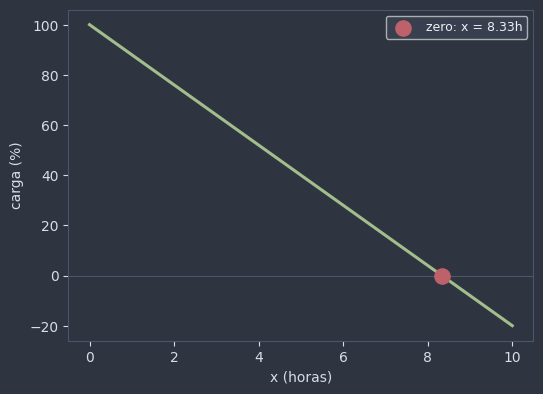

In [5]:
zero_bateria = -carga_inicial / taxa_consumo
print(f"zero: x = -b/a = -({carga_inicial})/({taxa_consumo}) = {zero_bateria:.2f} horas")

horas_completas = int(zero_bateria)
minutos = round((zero_bateria - horas_completas) * 60)
print(f"ou seja, aproximadamente {horas_completas}h{minutos:02d}min de bateria")

xs_zero = np.linspace(0, 10, 200)
fig, ax = plt.subplots(figsize=(6, 4.3))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.plot(xs_zero, funcao_afim(xs_zero, taxa_consumo, carga_inicial), color=COR_DESTAQUE, linewidth=2.2)
ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
ax.scatter(
    [zero_bateria], [0], s=120, color=COR_ALERTA, zorder=3,
    label=f"zero: x = {zero_bateria:.2f}h",
)
ax.set_xlabel("x (horas)", color=NORD_TEXTO_SEC)
ax.set_ylabel("carga (%)", color=NORD_TEXTO_SEC)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=9)
plt.show()

**Perguntas de checagem:**
1. Se a bateria começasse com 100% mas consumisse só metade da taxa (a = -6 em vez de -12), o zero seria maior, menor ou igual ao valor calculado acima? Por quê?
2. Uma função constante (a = 0) tem zero? O que acontece com a fórmula x = -b/a nesse caso?

## Funções afins crescentes e decrescentes

- Volte ao slider da seção anterior e repare: quando a é positivo, a reta "sobe" da esquerda para a direita; quando a é negativo, ela "desce"; quando a = 0, a reta fica na horizontal (nem sobe nem desce).
- 📌 **Definição formal** (retomando o notebook anterior): f é **crescente** em um intervalo se x1 < x2 ⟹ f(x1) < f(x2); é **decrescente** se x1 < x2 ⟹ f(x1) > f(x2).

## Teorema: o sinal de a decide tudo

- 📌 **Teorema:** para f(x) = ax + b,
    - f é **crescente** em toda a reta ⟺ a > 0;
    - f é **decrescente** em toda a reta ⟺ a < 0;
    - f é **constante** em toda a reta ⟺ a = 0.
- **Justificativa (informal):** tome x1 < x2. Então f(x2) - f(x1) = a(x2 - x1). Como x2 - x1 > 0, o sinal de f(x2) - f(x1) é exatamente o sinal de a — por isso a decide sozinho se a função cresce, decresce ou fica parada.
- No cenário da bateria, a = -12 < 0: a função é decrescente em toda a reta, o que bate com a intuição — a carga só diminui com o tempo.
- 🕵️ **Curiosidade histórica:** o termo "coeficiente angular" existe porque a é, literalmente, a tangente do ângulo que a reta forma com o eixo x. Essa conexão entre inclinação de retas e razões trigonométricas remonta à geometria analítica de René Descartes e Pierre de Fermat, no século XVII — assunto que reencontramos com mais detalhes no módulo `07_geometria_analitica_plana_e_espacial`.

**Perguntas de checagem:**
1. Duas funções afins têm o mesmo a = 5, mas b diferentes. As duas são crescentes? Elas têm o mesmo gráfico?
2. É possível uma função afim ser crescente em um trecho do domínio e decrescente em outro? (compare com a função de temperatura do notebook anterior, que era crescente num trecho e decrescente em outro)

## Estudar o sinal de uma função

- 📌 Estudar o sinal de uma função f significa descobrir, para cada valor de x do domínio, se f(x) é positivo, negativo ou zero.
- Isso é útil sempre que precisamos comparar uma função com zero — por exemplo, para saber quando um lucro é positivo, quando uma bateria ainda tem carga, ou — como veremos a seguir — para resolver inequações.

## Sinal da função afim

- 📌 **Quadro de sinais:** para f(x) = ax+b com a ≠ 0, o zero x = -b/a divide a reta real em duas partes, e o sinal de f muda exatamente nesse ponto.
    - Se **a > 0** (crescente): f(x) < 0 para x < -b/a; f(x) = 0 em x = -b/a; f(x) > 0 para x > -b/a.
    - Se **a < 0** (decrescente): f(x) > 0 para x < -b/a; f(x) = 0 em x = -b/a; f(x) < 0 para x > -b/a.
- 💡 **Dica:** não precisa decorar qual lado é qual — o sinal de f "acompanha" o sinal de a depois do zero, e é o oposto antes dele (e vice-versa se a < 0).

In [6]:
def explorar_sinal(a: float, b: float) -> None:
    if a == 0:
        print("a = 0 -> função constante, o sinal não depende de x")
        return

    zero = -b / a
    xs = np.linspace(zero - 6, zero + 6, 400)
    ys = funcao_afim(xs, a, b)

    fig, (eixo_grafico, eixo_reta) = plt.subplots(2, 1, figsize=(7, 5.5), height_ratios=[3, 1])
    fig.patch.set_facecolor(NORD_FUNDO)
    for eixo in (eixo_grafico, eixo_reta):
        estilizar_eixo(eixo)

    positivo = ys > 0
    negativo = ys < 0
    eixo_grafico.fill_between(xs, ys, 0, where=positivo, color=COR_DESTAQUE, alpha=0.35, interpolate=True)
    eixo_grafico.fill_between(xs, ys, 0, where=negativo, color=COR_ALERTA, alpha=0.35, interpolate=True)
    eixo_grafico.plot(xs, ys, color=NORD_TEXTO, linewidth=2)
    eixo_grafico.axhline(0, color=NORD_LINHA, linewidth=0.8)
    eixo_grafico.axvline(zero, color=COR_PONTO, linewidth=1, linestyle="--")
    eixo_grafico.set_title(
        f"f(x) = {a:g}x + {b:g}   (zero em x = {zero:g})", color=NORD_TEXTO, fontsize=10.5,
    )

    esquerda_positiva = a < 0
    cor_esquerda = COR_DESTAQUE if esquerda_positiva else COR_ALERTA
    cor_direita = COR_ALERTA if esquerda_positiva else COR_DESTAQUE
    eixo_reta.axhline(0, color=NORD_LINHA, linewidth=1)
    eixo_reta.plot([xs.min(), zero], [0, 0], color=cor_esquerda, linewidth=6, solid_capstyle="butt")
    eixo_reta.plot([zero, xs.max()], [0, 0], color=cor_direita, linewidth=6, solid_capstyle="butt")
    eixo_reta.scatter([zero], [0], s=80, color=NORD_TEXTO, zorder=3)
    eixo_reta.set_yticks([])
    eixo_reta.set_xlim(xs.min(), xs.max())

    plt.tight_layout()
    plt.show()

    sinal_esquerda = "positiva" if esquerda_positiva else "negativa"
    sinal_direita = "negativa" if esquerda_positiva else "positiva"
    print(f"para x < {zero:g}: f(x) é {sinal_esquerda}")
    print(f"para x = {zero:g}: f(x) = 0")
    print(f"para x > {zero:g}: f(x) é {sinal_direita}")


widgets.interact(
    explorar_sinal,
    a=widgets.FloatSlider(value=-2.0, min=-5, max=5, step=0.5, description="a:"),
    b=widgets.FloatSlider(value=4.0, min=-10, max=10, step=0.5, description="b:"),
)

interactive(children=(FloatSlider(value=-2.0, description='a:', max=5.0, min=-5.0, step=0.5), FloatSlider(valu…

<function __main__.explorar_sinal(a: float, b: float) -> None>

**Perguntas de checagem:**
1. Para f(x) = 3x - 9 (zero em x = 3, a = 3 > 0), qual o sinal de f(x) quando x = 10? E quando x = 0?
2. Sem calcular nada, o que muda no quadro de sinais se trocarmos a = 3 por a = -3, mantendo o mesmo zero?

## Inequações do 1º grau

- 📌 Uma inequação do 1º grau tem a forma ax + b > 0 (ou <, ≥, ≤), e resolvê-la significa encontrar todos os valores de x que tornam a desigualdade verdadeira — ou seja, usar exatamente o quadro de sinais que acabamos de construir.
- ⚠️ **Erro comum:** ao isolar x, se for preciso multiplicar ou dividir os dois lados por um número **negativo**, a desigualdade **inverte de sentido** (> vira <, e vice-versa). Esquecer isso é o erro mais comum ao resolver inequações.

solução de -12x + 100 > 40: Interval.open(-oo, 5)
ou seja: por menos de 5 horas de jogo, a bateria continua acima de 40%


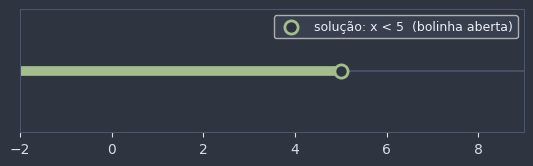

In [8]:
limite_bateria = 40
solucao_simples = sp.solveset(
    funcao_afim(x_sym, taxa_consumo, carga_inicial) > limite_bateria, x_sym, domain=sp.S.Reals,
)
print(f"solução de {taxa_consumo}x + {carga_inicial} > {limite_bateria}: {solucao_simples}")
print("ou seja: por menos de 5 horas de jogo, a bateria continua acima de 40%")

limite_solucao = float(solucao_simples.sup)

fig, ax = plt.subplots(figsize=(6.5, 1.6))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.axhline(0, color=NORD_LINHA, linewidth=1.2)
ax.plot([-2, limite_solucao], [0, 0], color=COR_DESTAQUE, linewidth=7, solid_capstyle="butt")
ax.scatter(
    [limite_solucao], [0], s=90, facecolors=NORD_FUNDO, edgecolors=COR_DESTAQUE, linewidths=2, zorder=3,
    label=f"solução: x < {limite_solucao:g}  (bolinha aberta)",
)
ax.set_yticks([])
ax.set_xlim(-2, 9)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=9, loc="upper right")
plt.show()

## Inequações simultâneas

- 📌 **Definição:** um sistema de inequações simultâneas exige que **duas ou mais** inequações sejam verdadeiras ao mesmo tempo, para o mesmo x.
- **Método:** resolvemos cada inequação separadamente e depois fazemos a **interseção** dos conjuntos-solução — só sobra o que satisfaz todas ao mesmo tempo.

20 <= carga <= 60  ->  Interval(10/3, 20/3)
a bateria fica entre 20% e 60% de 3.33h até 6.67h de jogo


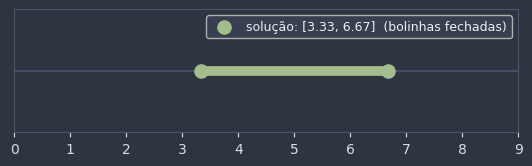

In [9]:
sol_a = sp.solveset(funcao_afim(x_sym, taxa_consumo, carga_inicial) >= 20, x_sym, domain=sp.S.Reals)
sol_b = sp.solveset(funcao_afim(x_sym, taxa_consumo, carga_inicial) <= 60, x_sym, domain=sp.S.Reals)
solucao_simultanea = sol_a.intersect(sol_b)
print(f"20 <= carga <= 60  ->  {solucao_simultanea}")

lim_inf = float(solucao_simultanea.inf)
lim_sup = float(solucao_simultanea.sup)
print(f"a bateria fica entre 20% e 60% de {lim_inf:.2f}h até {lim_sup:.2f}h de jogo")

fig, ax = plt.subplots(figsize=(6.5, 1.6))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.axhline(0, color=NORD_LINHA, linewidth=1.2)
ax.plot([lim_inf, lim_sup], [0, 0], color=COR_DESTAQUE, linewidth=7, solid_capstyle="butt")
ax.scatter(
    [lim_inf, lim_sup], [0, 0], s=90, color=COR_DESTAQUE, zorder=3,
    label=f"solução: [{lim_inf:.2f}, {lim_sup:.2f}]  (bolinhas fechadas)",
)
ax.set_yticks([])
ax.set_xlim(0, 9)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=9, loc="upper right")
plt.show()

**Perguntas de checagem:**
1. Por que resolver um sistema de inequações simultâneas significa fazer a **interseção**, e não a união, dos conjuntos-solução?
2. No exemplo acima, o que aconteceria com o intervalo-solução se o limite inferior fosse 20% e o superior fosse... 15%? (dica: pense se esse sistema teria solução)

## Inequações-produto

- 📌 **Definição:** uma inequação-produto tem a forma f(x)·g(x) > 0 (ou outra desigualdade), com f e g funções afins.
- **Método:** construímos o quadro de sinais de f e de g separadamente e usamos a **regra de sinais do produto** (+·+ = +, -·- = +, +·- = -) para combinar os dois quadros em um só.

g(x) = x-1, h(x) = 5-x  ->  solução de g(x)*h(x) > 0: (1 < x) & (x < 5)


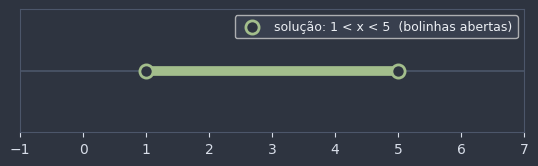

In [10]:
g_produto = x_sym - 1
h_produto = 5 - x_sym

solucao_produto = sp.solve_univariate_inequality((g_produto * h_produto) > 0, x_sym)
print(f"g(x) = x-1, h(x) = 5-x  ->  solução de g(x)*h(x) > 0: {solucao_produto}")

fig, ax = plt.subplots(figsize=(6.5, 1.6))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.axhline(0, color=NORD_LINHA, linewidth=1.2)
ax.plot([1, 5], [0, 0], color=COR_DESTAQUE, linewidth=7, solid_capstyle="butt")
ax.scatter(
    [1, 5], [0, 0], s=90, facecolors=NORD_FUNDO, edgecolors=COR_DESTAQUE, linewidths=2, zorder=3,
    label="solução: 1 < x < 5  (bolinhas abertas)",
)
ax.set_yticks([])
ax.set_xlim(-1, 7)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=9, loc="upper right")
plt.show()

## Inequações-quociente

- 📌 **Definição:** uma inequação-quociente tem a forma f(x)/g(x) > 0 (ou outra desigualdade), com f e g funções afins.
- ⚠️ **Erro comum:** esquecer de excluir os valores que zeram o **denominador** — eles ficam fora do domínio, mesmo que satisfizessem a desigualdade.
- **Método:** o mesmo quadro de sinais combinado da inequação-produto, com atenção redobrada: o zero do denominador é sempre marcado com **bolinha aberta**, nunca entra na solução.

(x+3)/(x-2) <= 0  ->  solução: (-3 <= x) & (x < 2)
repare que x=2 (zero do denominador) fica de fora, mesmo sendo o limite direito


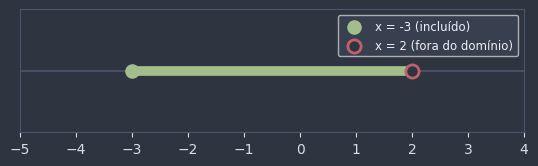

In [11]:
numerador = x_sym + 3
denominador = x_sym - 2

solucao_quociente = sp.solve_univariate_inequality((numerador / denominador) <= 0, x_sym)
print(f"(x+3)/(x-2) <= 0  ->  solução: {solucao_quociente}")
print("repare que x=2 (zero do denominador) fica de fora, mesmo sendo o limite direito")

fig, ax = plt.subplots(figsize=(6.5, 1.6))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.axhline(0, color=NORD_LINHA, linewidth=1.2)
ax.plot([-3, 2], [0, 0], color=COR_DESTAQUE, linewidth=7, solid_capstyle="butt")
ax.scatter([-3], [0], s=90, color=COR_DESTAQUE, zorder=3, label="x = -3 (incluído)")
ax.scatter(
    [2], [0], s=90, facecolors=NORD_FUNDO, edgecolors=COR_ALERTA, linewidths=2, zorder=3,
    label="x = 2 (fora do domínio)",
)
ax.set_yticks([])
ax.set_xlim(-5, 4)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=8.5, loc="upper right")
plt.show()

**Perguntas de checagem:**
1. Por que o zero do denominador nunca pode fazer parte da solução de uma inequação-quociente, mesmo quando a desigualdade é ≤ ou ≥?
2. Na inequação-produto (x-1)(5-x) > 0, o que mudaria na solução se a desigualdade fosse (x-1)(5-x) < 0?

## Retas paralelas e coincidentes

- 📌 Duas funções afins f(x) = a1x + b1 e g(x) = a2x + b2 têm gráficos **paralelos** quando a1 = a2 e b1 ≠ b2 (mesma inclinação, "alturas" diferentes), e **coincidentes** quando a1 = a2 e b1 = b2 (é a mesma reta).
- 📌 Vamos aprofundar retas paralelas — e também perpendiculares — com mais rigor em `07_geometria_analitica_plana_e_espacial`.

## Interseção de duas retas

- Encontrar o ponto onde dois gráficos de funções afins se cruzam é resolver o sistema formado pelas suas duas leis — o mesmo tipo de sistema linear 2x2 que apareceu nas seções sobre "determinar a lei a partir de dois pontos".
- 📌 Sistemas lineares com mais equações e incógnitas, e métodos gerais de resolução, são o assunto do módulo `03_progressoes_matrizes_e_sistemas_lineares`.

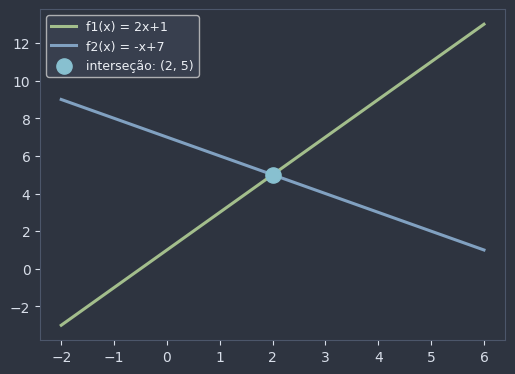

as retas se cruzam em x = 2, y = 5


In [12]:
def f1_fechamento(x):
    return 2 * x + 1


def f2_fechamento(x):
    return -x + 7


x_intersecao = sp.solve(sp.Eq(2 * x_sym + 1, -x_sym + 7), x_sym)[0]
y_intersecao = f1_fechamento(x_intersecao)

xs_fechamento = np.linspace(-2, 6, 200)
fig, ax = plt.subplots(figsize=(6, 4.3))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.plot(xs_fechamento, f1_fechamento(xs_fechamento), color=COR_DESTAQUE, linewidth=2.2, label="f1(x) = 2x+1")
ax.plot(xs_fechamento, f2_fechamento(xs_fechamento), color=COR_SECUNDARIA, linewidth=2.2, label="f2(x) = -x+7")
ax.scatter(
    [float(x_intersecao)], [float(y_intersecao)], s=120, color=COR_PONTO, zorder=3,
    label=f"interseção: ({float(x_intersecao):g}, {float(y_intersecao):g})",
)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=9)
plt.show()

print(f"as retas se cruzam em x = {x_intersecao}, y = {y_intersecao}")

## Resumo

- **Forma geral:** f(x) = ax + b, com a, b ∈ R.
- **Casos particulares:** constante (a=0), linear (b=0, proporcionalidade direta), identidade (a=1 e b=0).
- **Coeficientes:** a = coeficiente angular (inclinação da reta); b = coeficiente linear (valor de f(0), onde a reta corta o eixo y).
- **Imagem:** R se a ≠ 0; {b} se a = 0.
- **Zero:** x = -b/a (a ≠ 0) — onde a reta cruza o eixo x.
- **Crescente / decrescente / constante:** decidido só pelo sinal de a (a>0 / a<0 / a=0).
- **Quadro de sinais:** o zero -b/a divide a reta em duas partes; o sinal troca exatamente ali.
- **Inequações simples:** usar o quadro de sinais; inverter o sentido da desigualdade ao multiplicar/dividir por número negativo.
- **Inequações simultâneas:** resolver cada uma separadamente e fazer a interseção das soluções.
- **Inequações-produto:** combinar os quadros de sinais dos fatores pela regra de sinais.
- **Inequações-quociente:** igual à inequação-produto, mas excluindo sempre o zero do denominador (bolinha aberta).

## Exercícios

**Básico**
1. Dada uma função afim, identificar os coeficientes a e b, calcular o zero e classificar como crescente, decrescente ou constante.
2. Classificar funções afins dadas em constante, linear, identidade ou nenhuma das anteriores.

**Intermediário**
1. Determinar a lei de uma função afim a partir de dois pontos conhecidos.
2. Estudar o sinal de uma função afim dada.
3. Resolver uma inequação do 1º grau simples.

**Desafio**
1. Resolver uma inequação-produto em um contexto aplicado.
2. Resolver uma inequação-quociente em um contexto aplicado, com restrição de domínio.

Gabarito completo em [`017b_funcoes_primeiro_grau_gabarito.ipynb`](017b_funcoes_primeiro_grau_gabarito.ipynb).

### Básico

In [ ]:
# Exercício Básico 1: dada f(x) = 4x - 20 (por exemplo, o lucro em reais de
# uma banca de doces: R$4 por unidade vendida menos R$20 de custo fixo),
# identifique os coeficientes, o zero da função e classifique-a em
# crescente, decrescente ou constante.
coef_angular_ex = ...   # valor de a
coef_linear_ex = ...    # valor de b
zero_ex = ...            # valor de x tal que f(x) = 0
classificacao_ex = ...   # "crescente", "decrescente" ou "constante"

print(coef_angular_ex, coef_linear_ex, zero_ex, classificacao_ex)

In [ ]:
# Verificação
assert coef_angular_ex == 4, (
    "Tente de novo, revise o passo 1: compare f(x) = 4x-20 com f(x) = ax+b."
)
assert coef_linear_ex == -20, (
    "Tente de novo, revise o passo 1: compare f(x) = 4x-20 com f(x) = ax+b."
)
assert zero_ex == 5, "Tente de novo, revise o passo 2: resolva 4x-20 = 0."
assert classificacao_ex == "crescente", (
    "Tente de novo, revise o passo 3: o sinal de a decide -- aqui a = 4 > 0."
)
print("Certo!")

In [ ]:
# Exercício Básico 2: classifique cada função em "constante", "linear",
# "identidade" ou "nenhuma das anteriores"
def q1(x):
    return 7


def q2(x):
    return -3 * x


def q3(x):
    return x


def q4(x):
    return 2 * x + 1


classificacao_q1 = ...
classificacao_q2 = ...
classificacao_q3 = ...
classificacao_q4 = ...

print(classificacao_q1, classificacao_q2, classificacao_q3, classificacao_q4)

In [ ]:
# Verificação
assert classificacao_q1 == "constante", (
    "Tente de novo, revise o passo 1: q1(x) = 7 não depende de x (a = 0)."
)
assert classificacao_q2 == "linear", (
    "Tente de novo, revise o passo 1: q2(x) = -3x tem b = 0."
)
assert classificacao_q3 == "identidade", (
    "Tente de novo, revise o passo 1: q3(x) = x tem a = 1 e b = 0."
)
assert classificacao_q4 == "nenhuma das anteriores", (
    "Tente de novo, revise o passo 1: q4(x) = 2x+1 tem a != 0, 1 e b != 0."
)
print("Certo!")

### Intermediário

In [ ]:
# Exercício Intermediário 1: uma planta cresce a taxa constante. Depois de
# 2 semanas, mede 14 cm; depois de 5 semanas, mede 26 cm. Determine a lei
# h(x) = a*x + b (a e b), resolvendo o sistema com sympy.
a_sym_ex, b_sym_ex = sp.symbols("a b")
eq1_ex = sp.Eq(a_sym_ex * 2 + b_sym_ex, 14)
eq2_ex = sp.Eq(a_sym_ex * 5 + b_sym_ex, 26)

solucao_planta_ex = ...  # dica: sp.solve([eq1_ex, eq2_ex], [a_sym_ex, b_sym_ex])
a_planta_ex = ...  # dica: solucao_planta_ex[a_sym_ex]
b_planta_ex = ...  # dica: solucao_planta_ex[b_sym_ex]

print(a_planta_ex, b_planta_ex)

In [ ]:
# Verificação
esperado_planta = sp.solve([eq1_ex, eq2_ex], [a_sym_ex, b_sym_ex])
assert solucao_planta_ex == esperado_planta, (
    "Tente de novo, revise o passo 1: use sp.solve([eq1_ex, eq2_ex], [a_sym_ex, b_sym_ex])."
)
assert a_planta_ex == esperado_planta[a_sym_ex], (
    "Tente de novo, revise o passo 2: pegue solucao_planta_ex[a_sym_ex]."
)
assert b_planta_ex == esperado_planta[b_sym_ex], (
    "Tente de novo, revise o passo 2: pegue solucao_planta_ex[b_sym_ex]."
)
assert (a_planta_ex, b_planta_ex) == (4, 6), (
    "Confira: (26-14)/(5-2) = 4 (taxa de crescimento) e 14 - 4*2 = 6 (altura em x=0)."
)
print("Certo!")

In [ ]:
# Exercício Intermediário 2: estude o sinal de f(x) = -5x + 35. Informe o
# zero e os intervalos (como tuplas) onde f é positiva e onde é negativa
# -- use float("-inf") / float("inf") para os lados sem limite.
zero_sinal_ex = ...
intervalo_positivo_ex = ...  # tupla (a, b)
intervalo_negativo_ex = ...  # tupla (a, b)

print(zero_sinal_ex, intervalo_positivo_ex, intervalo_negativo_ex)

In [ ]:
# Verificação
assert zero_sinal_ex == 7, "Tente de novo, revise o passo 1: resolva -5x+35 = 0."
assert intervalo_positivo_ex == (float("-inf"), 7), (
    "Tente de novo, revise o passo 2: a = -5 < 0 -> f é positiva antes do zero."
)
assert intervalo_negativo_ex == (7, float("inf")), (
    "Tente de novo, revise o passo 2: a = -5 < 0 -> f é negativa depois do zero."
)
print("Certo!")

In [ ]:
# Exercício Intermediário 3: resolva a inequação 3x - 12 < 0 usando
# sp.solveset, e guarde o conjunto-solução.
solucao_inequacao_ex = ...  # dica: sp.solveset(3*x_sym - 12 < 0, x_sym, domain=sp.S.Reals)

print(solucao_inequacao_ex)

In [ ]:
# Verificação
esperado_inequacao = sp.solveset(3 * x_sym - 12 < 0, x_sym, domain=sp.S.Reals)
assert solucao_inequacao_ex == esperado_inequacao, (
    "Tente de novo, revise o passo 1: isole x em 3x-12 < 0 (cuidado: aqui não "
    "há inversão, pois dividimos por 3, que é positivo)."
)
print("Certo!")

### Desafio

In [ ]:
# Exercício Desafio 1: o lucro (em milhares de reais) de uma empresa, em
# função das x centenas de unidades vendidas, é dado por
# L(x) = (x - 10)(50 - x). Para quais valores de x o lucro é positivo?
# (dica: sp.solve_univariate_inequality)
lucro_ex = (x_sym - 10) * (50 - x_sym)

solucao_lucro_ex = ...  # dica: sp.solve_univariate_inequality(lucro_ex > 0, x_sym)

print(solucao_lucro_ex)

In [ ]:
# Verificação
esperado_lucro = sp.solve_univariate_inequality(lucro_ex > 0, x_sym)
assert solucao_lucro_ex == esperado_lucro, (
    "Tente de novo, revise o passo 1: L(x) é um produto de duas funções "
    "afins com zeros em x=10 e x=50 -- monte o quadro de sinais combinado."
)
print("Certo!")

In [ ]:
# Exercício Desafio 2: uma métrica de eficiência é dada por
# E(x) = (x - 8) / (x - 3), com x != 3 (fora do domínio). Para quais
# valores de x temos E(x) >= 0? (dica: sp.solve_univariate_inequality,
# lembre de excluir x=3 do domínio)
eficiencia_ex = (x_sym - 8) / (x_sym - 3)

solucao_eficiencia_ex = ...  # dica: sp.solve_univariate_inequality(eficiencia_ex >= 0, x_sym)

print(solucao_eficiencia_ex)

In [ ]:
# Verificação
esperado_eficiencia = sp.solve_univariate_inequality(eficiencia_ex >= 0, x_sym)
assert solucao_eficiencia_ex == esperado_eficiencia, (
    "Tente de novo, revise o passo 1: monte o quadro de sinais de "
    "(x-8) e (x-3) e combine pela regra de sinais do quociente, "
    "lembrando de excluir x=3."
)
print("Certo!")

## Conexões

**Isso depende de:**
- [`015a_funcoes.ipynb`](015a_funcoes.ipynb) (conceito de função, domínio/contradomínio/imagem, gráfico no plano cartesiano)
- [`016a_classificacao_e_operacoes_com_funcoes.ipynb`](016a_classificacao_e_operacoes_com_funcoes.ipynb) (funções crescentes e decrescentes)
- [00_fundamentos_e_python/](../00_fundamentos_e_python/) (Python básico) e resolução de equações do 1º grau

**Isso será usado em:**
- [`03_progressoes_matrizes_e_sistemas_lineares/`](../03_progressoes_matrizes_e_sistemas_lineares/) (sistemas lineares, incluindo a interseção de retas)
- [`07_geometria_analitica_plana_e_espacial/`](../07_geometria_analitica_plana_e_espacial/) (retas paralelas/coincidentes, coeficiente angular)
- Próximo notebook de funções (2º grau), para contraste entre reta e parábola, e entre crescente/decrescente x vértice
- [`11_limite_integral_e_derivada/`](../11_limite_integral_e_derivada/) (coeficiente angular como antecipação da taxa de variação/derivada)